![header](https://drive.google.com/uc?export=view&id=1KuEspEp7OwqGw6uMRJvYE6BVE-Zo-8JF)

 <h1> <div align="center"> Dr. David Antonio-Torres</div> </h1>

# Redes Neuronales Convolucionales
### Se hace uso del dataset CIFAR-10 para reconocimiento de 10 objetos
### 0 - airplane
### 1 - automobile
### 2 - bird
### 3 - cat
### 4 - deer
### 5 - dog
### 6 - frog
### 7 - horse
### 8 - ship
### 9 - truck
### https://keras.io/api/datasets/cifar10/

## Entorno de ejecución y referencias

🔗 **Repositorio GitHub:** [https://github.com/joelbecv/MNA_WORKSPACE](https://github.com/joelbecv/MNA_WORKSPACE)  
📁 **Archivo:** `4.4 cnn_keras_b.ipynb`

### ¿Dónde puedo correr este notebook?

| Entorno | Estado | Tiempo estimado | Recomendación |
|---------|--------|-----------------|---------------|
| 💻 Mac M5 (local) | ✅ Funciona | **~25-35 minutos** con Metal GPU | Asegúrate de tener Metal GPU activo |
| ☁️ Google Colab | ✅ Funciona | ~10 minutos con GPU | Cambiar runtime a GPU: Entorno → Cambiar tipo de entorno de ejecución → T4 GPU |

⚠️ Notebook más pesado de la semana. Batch=32 sobre 50k imágenes = 1562 pasos por época × 10 épocas. Si no tienes prisa, corre en Colab con GPU gratuita.

### 🔧 Cambios ya aplicados en este notebook para TF 2.18

Estos imports del original **dan error en TF 2.18** porque Keras 3 reorganizó sus módulos:

```python
# ANTES (Colab/Keras 2) — DA ERROR en TF 2.18
from keras.layers.convolutional import Conv2D        # ← módulo eliminado en Keras 3
from keras.layers.convolutional import MaxPooling2D  # ← módulo eliminado en Keras 3
from keras.utils.np_utils import to_categorical      # ← módulo eliminado en Keras 3
Adam(lr=0.01)                                         # ← parámetro renombrado

# DESPUÉS (TF 2.18) — versión correcta
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.utils import to_categorical
Adam(learning_rate=0.01)
```

**¿Por qué cambiaron estas rutas?** Keras 3 (incluido en TF 2.16+) reorganizó sus módulos internos para simplificarlos. `keras.layers.convolutional` como subpaquete separado dejó de existir — ahora todas las capas están directamente en `keras.layers`.

## ¿Qué hace este notebook?

Entrena una CNN más profunda para clasificar **10 categorías de imágenes reales** del dataset CIFAR-10.

### El dataset CIFAR-10

- **60,000 imágenes** de 10 categorías: avión, automóvil, pájaro, gato, ciervo, perro, rana, caballo, barco, camión
- Cada imagen es **32×32 píxeles en color** (3 canales: Rojo, Verde, Azul)
- Mucho más difícil que MNIST: las imágenes tienen fondos variables, iluminación distinta, ángulos distintos

### Diferencia con 4.4a (CNN MNIST):

| Aspecto | 4.4a MNIST | 4.4b CIFAR-10 |
|---------|-----------|---------------|
| Tamaño imagen | 28×28 (1 canal gris) | 32×32 (3 canales color) |
| Clases | 10 dígitos | 10 objetos reales |
| Dificultad | Baja | **Alta** |
| Capas Conv2D | 2 | **6** |
| Batch size | 400 | **32** (más pequeño) |
| Tiempo M5 | ~10 min | **~25-35 min** |

### ¿Por qué 6 capas convolucionales?
Las imágenes reales tienen patrones más complejos que dígitos. Se necesitan más capas para detectar:
- Capas 1-2: bordes, texturas simples
- Capas 3-4: formas más complejas (ruedas, alas)
- Capas 5-6: conceptos de alto nivel (vehículo completo, animal)

### ¿Por qué batch=32 y no 400?
CIFAR-10 es más ruidoso. Con batches más pequeños el modelo hace más actualizaciones por época y aprende más matices. El precio: más tiempo de entrenamiento.

# Se cargan las bibliotecas necesarias

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
import random
     
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
     
from tensorflow.keras.models import Model

np.random.seed(0)

# Se carga el dataset y se verifica el número de muestras en cada set
### Nótese que al hacer la carga, se genera automáticamente el set de entrenamiento y el set de pruebas
### Las imágenes son a color y de 32 por 32 pixeles

In [2]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
     
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)
print(type(X_train))

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 16s 0us/step
(50000, 32, 32, 3)
(10000, 32, 32, 3)
(50000, 1)
(10000, 1)
<class 'numpy.ndarray'>


# Se verifica el número de muestras por objeto

Text(0, 0.5, 'Número de Muestras')

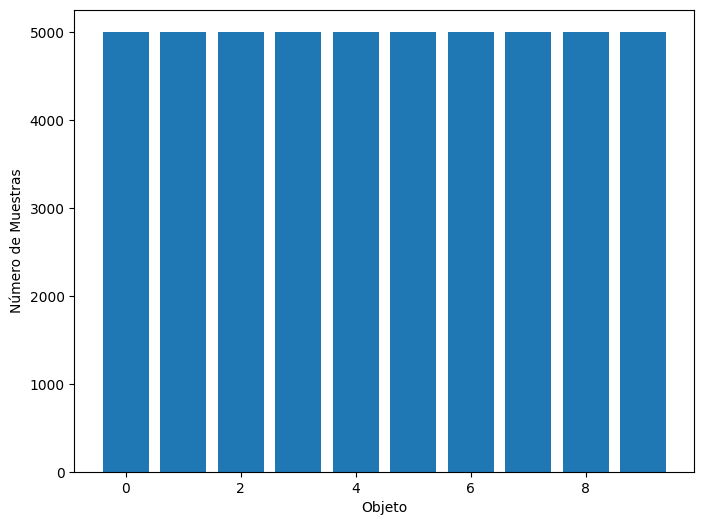

In [3]:
n_muestras = []
n_objetos = 10

for n in range(n_objetos):
    x_sel = X_train[y_train[:,0] == n]
    n_muestras.append(len(x_sel))
plt.figure(figsize=(8,6))
plt.bar(range(0,n_objetos), n_muestras)
plt.xlabel("Objeto")
plt.ylabel("Número de Muestras")

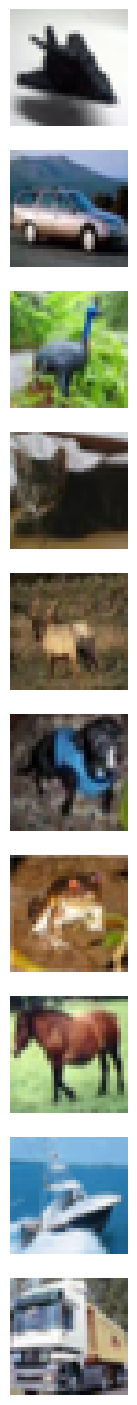

In [4]:
n_objetos = 10

fig, axs = plt.subplots(n_objetos, figsize=(18,18))
for n in range(n_objetos):
    x_sel = X_train[y_train[:,0] == n]
    axs[n].imshow(x_sel[0])
    axs[n].axis('off')

# One-hot Encoding para las etiquetas de ambos sets

In [5]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Se normalizan las intensidades de los pixeles en un intervalo de 0 y 1

In [6]:
X_train = X_train/255 
X_test = X_test/255

# Se define el modelo 
### El parámetro *input_shape* se toma de *X_train* para reflejar las dimensiones de las imágenes a color


In [7]:
model = Sequential()

model.add(Conv2D(filters = 32, kernel_size = (3, 3), input_shape = X_train.shape[1:], activation='relu', padding='same'))
model.add(Conv2D(filters = 32, kernel_size = (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
#model.add(AveragePooling2D())

model.add(Conv2D(filters = 64, kernel_size = (3, 3), activation='relu', padding='same'))
model.add(Conv2D(filters = 64, kernel_size = (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(filters = 64, kernel_size = (3, 3), activation='relu', padding='same'))
model.add(Conv2D(filters = 64, kernel_size = (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(units = 512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(units = 10, activation='softmax'))

model.compile(Adam(learning_rate= 0.001), loss='categorical_crossentropy', metrics=['accuracy'])
print(model.summary())

/Users/joelbecerril/miniconda3/envs/ml_env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-06-03 23:48:27.260976: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M5
2026-06-03 23:48:27.261016: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-06-03 23:48:27.261019: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
I0000 00:00:1780552107.261030 2100338 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1780552107.261051 2100338 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 6, 6, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,138 (1.05 MB)

 Trainable params: 276,138 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

None


# Se separa un 10% del set de entrenamiento para fines de validación

In [8]:
history = model.fit(X_train, y_train, validation_split=0.1, epochs = 10, batch_size = 32, verbose = 1, shuffle = True)

Epoch 1/10


2026-06-03 23:48:29.047916: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1407/1407 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.3484 - loss: 1.7395 - val_accuracy: 0.5140 - val_loss: 1.3276
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 28s 20ms/step - accuracy: 0.5226 - loss: 1.3191 - val_accuracy: 0.6082 - val_loss: 1.0816
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 28s 20ms/step - accuracy: 0.5794 - loss: 1.1797 - val_accuracy: 0.6446 - val_loss: 1.0247
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 28s 20ms/step - accuracy: 0.6103 - loss: 1.1219 - val_accuracy: 0.6730 - val_loss: 0.9079
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 28s 20ms/step - accuracy: 0.6233 - loss: 1.0846 - val_accuracy: 0.6692 - val_loss: 0.9404
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 29s 20ms/step - accuracy: 0.6355 - loss: 1.0656 - val_accuracy: 0.7016 - val_loss: 0.8588
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 28s 20ms/step - accuracy: 0.6452 - loss: 1.0527 - val_accuracy: 0.6900 - val_loss: 0.9049
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 28s 20ms/step - accuracy: 0.6487 - loss: 1.06

In [9]:
scores = model.evaluate(X_test, y_test, verbose=1)
print('Test loss:', scores[0])
print('Test accuracy:', scores[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6938 - loss: 0.9464
Test loss: 0.9464123845100403
Test accuracy: 0.6937999725341797


Text(0.5, 0, 'epoch')

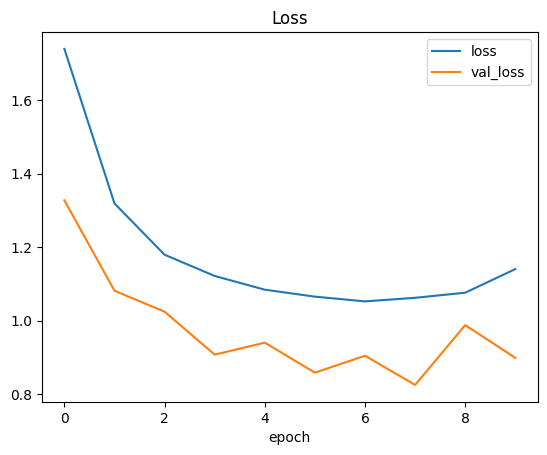

In [10]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.title('Loss')
plt.xlabel('epoch')

Text(0.5, 0, 'epoch')

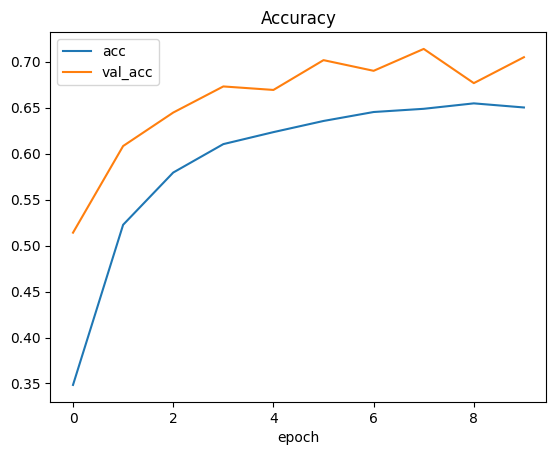

In [11]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['acc', 'val_acc'])
plt.title('Accuracy')
plt.xlabel('epoch')

# Se somete a prueba con una imagen de la web

In [13]:
import requests
from PIL import Image
     
url = 
response = requests.get(url, stream=True)
img = Image.open(response.raw)

SyntaxError: invalid syntax (2604059091.py, line 4)

In [ ]:
import cv2
     
img_arr = np.asarray(img)
img_rs = cv2.resize(img_arr, (32, 32, 3))
plt.imshow(img_rs)

In [ ]:
prediction = np.argmax(model.predict(img_rs), axis=-1)
print("objeto:", str(prediction))

# Gracias por la atención